In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import cosine_distances
from sklearn.metrics import pairwise_distances

# Change Working Dir To the Project Working Dir (for Noam)

In [2]:
import ipynbname
# change the dir to the grandparent directory of the current working directory

note_dir = ipynbname.path().parent
grandparent_dir = note_dir.parent.parent
os.chdir(grandparent_dir)
print(os.getcwd())  # Check the cwd has updated

c:\Users\noams\Python Projects\Audio_processing_project


# Classical Clustering

## Naive Clustering

In [3]:
raw_data = pd.read_csv(Path(r"TESS\TCAV\M with test Tcav_Tess_spk_shuffled.csv"))

In [4]:
raw_data

,path,concept_name,layer_name,positive_percentage,magnitude,cav_acc,true_label,predicted_label,predicted_probability
0,TESS\TESS_DATASET\train\OAF actor\OAF_make_sad...,long_constant_thick,module3.blocks.0.conv2,0.0,-0.348743,0.956522,sad,sad,0.993438
1,TESS\TESS_DATASET\train\OAF actor\OAF_make_sad...,long_dropping_flat_thick,module3.blocks.0.conv2,0.0,-0.875104,0.869565,sad,sad,0.993438
2,TESS\TESS_DATASET\train\OAF actor\OAF_make_sad...,long_dropping_steep_thick,module3.blocks.0.conv2,0.0,-0.577360,0.782609,sad,sad,0.993438
3,TESS\TESS_DATASET\train\OAF actor\OAF_make_sad...,long_dropping_steep_thin,module3.blocks.0.conv2,0.0,-0.826777,0.913043,sad,sad,0.993438
4,TESS\TESS_DATASET\train\OAF actor\OAF_make_sad...,long_rising_flat_thick,module3.blocks.0.conv2,1.0,0.024975,0.695652,sad,sad,0.993438
...,...,...,...,...,...,...,...,...,...
33595,TESS\TESS_DATASET\train\OAF actor\OAF_page_fea...,short_constant_thick,module3.blocks.0.conv2,0.0,-0.304147,0.826087,fearful,fearful,0.994170
33596,TESS\TESS_DATASET\train\OAF actor\OAF_page_fea...,short_dropping_steep_thick,module3.blocks.0.conv2,0.0,-0.042420,0.739130,fearful,fearful,0.994170
33597,TESS\TESS_DATASET\train\OAF actor\OAF_page_fea...,short_dropping_steep_thin,module3.blocks.0.conv2,0.0,-0.104145,0.826087,fearful,fearful,0.994170
33598,TESS\TESS_DATASET\train\OAF actor\OAF_page_fea...,short_rising_steep_thick,module3.blocks.0.conv2,0.0,-0.423845,0.956522,fearful,fearful,0.994170


In [5]:
data_matching_predictions = raw_data[raw_data["true_label"] == raw_data["predicted_label"]]

In [6]:
data_matching_predictions

,path,concept_name,layer_name,positive_percentage,magnitude,cav_acc,true_label,predicted_label,predicted_probability
0,TESS\TESS_DATASET\train\OAF actor\OAF_make_sad...,long_constant_thick,module3.blocks.0.conv2,0.0,-0.348743,0.956522,sad,sad,0.993438
1,TESS\TESS_DATASET\train\OAF actor\OAF_make_sad...,long_dropping_flat_thick,module3.blocks.0.conv2,0.0,-0.875104,0.869565,sad,sad,0.993438
2,TESS\TESS_DATASET\train\OAF actor\OAF_make_sad...,long_dropping_steep_thick,module3.blocks.0.conv2,0.0,-0.577360,0.782609,sad,sad,0.993438
3,TESS\TESS_DATASET\train\OAF actor\OAF_make_sad...,long_dropping_steep_thin,module3.blocks.0.conv2,0.0,-0.826777,0.913043,sad,sad,0.993438
4,TESS\TESS_DATASET\train\OAF actor\OAF_make_sad...,long_rising_flat_thick,module3.blocks.0.conv2,1.0,0.024975,0.695652,sad,sad,0.993438
...,...,...,...,...,...,...,...,...,...
33595,TESS\TESS_DATASET\train\OAF actor\OAF_page_fea...,short_constant_thick,module3.blocks.0.conv2,0.0,-0.304147,0.826087,fearful,fearful,0.994170
33596,TESS\TESS_DATASET\train\OAF actor\OAF_page_fea...,short_dropping_steep_thick,module3.blocks.0.conv2,0.0,-0.042420,0.739130,fearful,fearful,0.994170
33597,TESS\TESS_DATASET\train\OAF actor\OAF_page_fea...,short_dropping_steep_thin,module3.blocks.0.conv2,0.0,-0.104145,0.826087,fearful,fearful,0.994170
33598,TESS\TESS_DATASET\train\OAF actor\OAF_page_fea...,short_rising_steep_thick,module3.blocks.0.conv2,0.0,-0.423845,0.956522,fearful,fearful,0.994170


In [7]:
vector_df_glob = data_matching_predictions.pivot_table(
    index=["path", "true_label"],   # rows by recordingo
    columns="concept_name",      # each concept becomes its own column
    values="magnitude"          # the numeric values go in
).reset_index(drop = False)

In [8]:
vector_df_glob

concept_name,path,true_label,long_constant_thick,long_dropping_flat_thick,long_dropping_steep_thick,long_dropping_steep_thin,long_rising_flat_thick,long_rising_steep_thick,long_rising_steep_thin,short_constant_thick,short_dropping_steep_thick,short_dropping_steep_thin,short_rising_steep_thick,short_rising_steep_thin
0,TESS\TESS_DATASET\test\YAF actor\YAF_back_angr...,angry,-0.185365,-0.568790,-0.156071,-0.444167,0.020060,-0.324755,-0.061098,-0.189056,-0.097160,-0.288102,-0.233442,-0.007050
1,TESS\TESS_DATASET\test\YAF actor\YAF_back_disg...,disgusted,-0.352588,-1.134331,-0.202941,-0.816317,-0.025957,-0.723539,-0.164153,-0.225396,-0.098832,-0.573679,-0.368940,0.236502
2,TESS\TESS_DATASET\test\YAF actor\YAF_back_fear...,fearful,-0.413152,0.386936,-0.285435,-0.125140,-0.305761,-0.026199,0.057007,-0.321378,0.165672,0.115881,-0.187801,-0.493990
3,TESS\TESS_DATASET\test\YAF actor\YAF_back_happ...,happy,-0.295016,-0.185996,-0.291749,-0.352473,-0.034277,-0.136312,0.033121,-0.306249,0.078524,-0.211511,-0.197061,-0.215110
4,TESS\TESS_DATASET\test\YAF actor\YAF_back_neut...,neutral,0.167763,0.012842,0.042025,0.093851,0.096926,0.134017,0.192018,0.090699,0.107615,0.098711,0.087764,0.059778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2788,TESS\TESS_DATASET\train\OAF actor\OAF_youth_fe...,fearful,-0.821245,-0.304812,-0.646460,-0.638192,-0.557990,-0.573122,-0.824901,-0.533534,-0.418072,-0.287334,-0.903954,-0.862395
2789,TESS\TESS_DATASET\train\OAF actor\OAF_youth_ha...,happy,0.334207,0.480239,0.699039,0.499535,0.404041,0.305380,0.579197,0.311643,0.355577,0.208755,0.578513,0.499177
2790,TESS\TESS_DATASET\train\OAF actor\OAF_youth_ne...,neutral,0.537287,0.684967,0.136932,0.610739,0.118965,0.712270,0.236050,0.278707,0.085490,0.515997,0.496724,0.022731
2791,TESS\TESS_DATASET\train\OAF actor\OAF_youth_ps...,surprised,0.031705,-0.209271,0.203929,-0.114174,0.208978,-0.149717,0.085582,-0.031961,-0.026006,-0.129829,0.130195,0.173129


In [9]:
# average on true label
temp = vector_df_glob.drop(columns=['path']).groupby("true_label").mean().reset_index()
temp

concept_name,true_label,long_constant_thick,long_dropping_flat_thick,long_dropping_steep_thick,long_dropping_steep_thin,long_rising_flat_thick,long_rising_steep_thick,long_rising_steep_thin,short_constant_thick,short_dropping_steep_thick,short_dropping_steep_thin,short_rising_steep_thick,short_rising_steep_thin
0,angry,-0.051174,-0.358118,-0.057710,-0.254489,0.071770,-0.162816,0.061190,-0.071245,0.008753,-0.174927,-0.021139,0.117014
1,disgusted,-0.077023,-0.743829,0.144704,-0.399987,0.100095,-0.490391,-0.025984,0.024290,-0.021905,-0.302661,-0.149466,0.365166
2,fearful,-0.447312,0.008039,-0.280696,-0.228488,-0.337753,-0.269598,-0.298200,-0.223102,-0.115950,-0.063344,-0.445667,-0.463917
3,happy,0.120079,0.281974,0.172121,0.238586,0.056973,0.195528,0.204968,0.154767,0.164307,0.153825,0.189835,0.089168
4,neutral,0.415472,0.170717,0.183475,0.285170,0.232876,0.345615,0.249779,0.171804,0.073760,0.207135,0.342002,0.150379
5,sad,-0.463779,-0.847344,-0.548369,-0.877974,-0.075937,-0.778165,-0.578241,-0.664332,-0.488429,-0.685978,-0.821350,-0.615839
6,surprised,0.017015,-0.027123,0.131585,-0.034289,0.064610,-0.062645,0.076640,-0.028347,0.014471,-0.010232,0.048957,0.062660


In [10]:
# Features (X) and labels (y)
X = vector_df_glob.drop(columns=["path", "true_label"], inplace=False).to_numpy()
y = vector_df_glob["true_label"].to_numpy()

In [11]:
X.shape, y.shape

((2793, 12), (2793,))

In [12]:
# added by Noam as KMeans has a known bug when on Windows using MKL with multithreading.
import os
os.environ["OMP_NUM_THREADS"] = "6"
# end of addition

In [13]:
def intra_inter_scores(X, y, metric="euclidean"):
    """Compute intra- and inter-cluster distance statistics for labels y using the given metric.

    Returns:
      - intra_mean: mean of within-class pairwise distances
      - inter_mean: mean of between-class pairwise distances
      - separation: inter_mean / intra_mean
    """
    # 1) Compute pairwise distance matrix for the chosen metric
    dist_matrix = pairwise_distances(X, metric=metric)
    # 2) Unique label identifiers present in y
    labels = np.unique(y)

    # 3) Accumulators for intra- and inter-class distances
    intra_dists = []
    inter_dists = []

    # 4) Intra-class distances: average of upper triangle (exclude diagonal)
    for label in labels:
        idx = np.where(y == label)[0]
        if len(idx) > 1:
            d = dist_matrix[np.ix_(idx, idx)]
            intra_dists.append(d[np.triu_indices_from(d, k=1)].mean())

    # 5) Inter-class distances: mean distances across class pairs
    for i, lbl1 in enumerate(labels):
        for lbl2 in labels[i+1:]:
            idx1 = np.where(y == lbl1)[0]
            idx2 = np.where(y == lbl2)[0]
            d = dist_matrix[np.ix_(idx1, idx2)]
            inter_dists.append(d.mean())

    # 6) Aggregate metrics
    return {
        "intra_mean": np.mean(intra_dists),
        "inter_mean": np.mean(inter_dists),
        "separation": np.mean(inter_dists) / np.mean(intra_dists)
    }

In [14]:
from sklearn.preprocessing import normalize


def evaluate_clustering(X, y, n_clusters, random_state=42, print_results=True, return_results=False):
    # KMeans clustering with Euclidean distance
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
    clusters_euc = kmeans.fit_predict(X)
    
    # KMeans clustering with Cosine distance
    X_cosine = normalize(X, norm='l2', axis=1)        # put points on the unit sphere
    clusters_cos = kmeans.fit_predict(X_cosine)
    
    if print_results:
        # ---- STEP 4: Evaluation (since you have ground truth labels) ----
        print("Euclidean clustering ARI:", adjusted_rand_score(y, clusters_euc))
        print("Cosine clustering ARI:", adjusted_rand_score(y, clusters_cos))
        print("Euclidean Silhouette:", silhouette_score(X, clusters_euc, metric="euclidean"))
        print("Cosine Silhouette:", silhouette_score(X_cosine, clusters_cos, metric="cosine"))
        
        # Intra-cluster and inter-cluster scores
        print("Euclidean:", intra_inter_scores(X, clusters_euc, metric="euclidean"))
        print("Cosine:", intra_inter_scores(X, clusters_cos, metric="cosine"))
    
    if return_results:
        return {
                    "Euclidean clustering ARI": adjusted_rand_score(y, clusters_euc),
                    "Cosine clustering ARI": adjusted_rand_score(y, clusters_cos),
                    "Euclidean Silhouette": silhouette_score(X, clusters_euc, metric="euclidean"),
                    "Cosine Silhouette": silhouette_score(X_cosine, clusters_cos, metric="cosine"),
                    "Euclidean": intra_inter_scores(X, clusters_euc, metric="euclidean"),
                    "Cosine": intra_inter_scores(X, clusters_cos, metric="cosine")
                }

## Hyperparameter Evaluation of Naive Clustering

In [15]:
evaluate_clustering(X, y, n_clusters=4, print_results=True)

c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(


Euclidean clustering ARI: 0.3812997066005354
Cosine clustering ARI: 0.3450620064342388
Euclidean Silhouette: 0.4102009313335746
Cosine Silhouette: 0.5845463288666591
Euclidean: {'intra_mean': 0.7891661937495442, 'inter_mean': 1.929545341518781, 'separation': 2.445043080660848}
Cosine: {'intra_mean': 0.23270440585700267, 'inter_mean': 1.1311524701360176, 'separation': 4.860898382951603}


In [16]:
evaluate_clustering(X, y, n_clusters=5, print_results=True)

c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(


Euclidean clustering ARI: 0.39489017267706245
Cosine clustering ARI: 0.34969716418370916
Euclidean Silhouette: 0.35811931021553384
Cosine Silhouette: 0.57266864173384
Euclidean: {'intra_mean': 0.7184140485858612, 'inter_mean': 1.8975689289008666, 'separation': 2.641330487114046}
Cosine: {'intra_mean': 0.2333640952939034, 'inter_mean': 1.0951002492287418, 'separation': 4.692668115245195}


In [17]:
evaluate_clustering(X, y, n_clusters=6, print_results=True)

c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(


Euclidean clustering ARI: 0.36855289762745486
Cosine clustering ARI: 0.3857467201634881
Euclidean Silhouette: 0.3304854068271798
Cosine Silhouette: 0.5516285643875145
Euclidean: {'intra_mean': 0.6778290894456558, 'inter_mean': 1.9119224342749273, 'separation': 2.8206556255036817}
Cosine: {'intra_mean': 0.21647172643022153, 'inter_mean': 1.0784064226560663, 'separation': 4.981742606481612}


In [18]:
evaluate_clustering(X, y, n_clusters=8, print_results=True)

c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(


Euclidean clustering ARI: 0.39398718121902565
Cosine clustering ARI: 0.4048160971424753
Euclidean Silhouette: 0.3085865067227893
Cosine Silhouette: 0.4322779420768678
Euclidean: {'intra_mean': 0.6116426303799302, 'inter_mean': 1.8171417735666286, 'separation': 2.970920735917126}
Cosine: {'intra_mean': 0.18275385048897488, 'inter_mean': 1.0836656860072749, 'separation': 5.929646259752267}


In [ ]:
# Features (X) and labels (y)
vector_df_glob_fix = vector_df_glob.copy()
# remove happy and neutral
vector_df_glob_fix = vector_df_glob_fix[vector_df_glob_fix["true_label"] != "happy" ]
vector_df_glob_fix = vector_df_glob_fix[vector_df_glob_fix["true_label"] != "neutral" ]
vector_df_glob_fix
X_wo_h_n = vector_df_glob_fix.drop(columns=["path", "true_label"], inplace=False).to_numpy()
y_wo_h_n = vector_df_glob_fix["true_label"].to_numpy()

In [ ]:
cluster_dict = {num:evaluate_clustering(X_wo_h_n, y_wo_h_n, n_clusters=num, return_results=True, print_results=False) for num in range(2, 11)}
cluster_dict

c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

{2: {'Euclidean clustering ARI': 0.19086754195824168,
  'Cosine clustering ARI': 0.09017013787337788,
  'Euclidean Silhouette': 0.4263094230078531,
  'Cosine Silhouette': 0.6004782687657317,
  'Euclidean': {'intra_mean': 1.036156083442108,
   'inter_mean': 1.9089347202864144,
   'separation': 1.842323517461711},
  'Cosine': {'intra_mean': 0.4690922870232397,
   'inter_mean': 1.1477409160827652,
   'separation': 2.4467273238835068}},
 3: {'Euclidean clustering ARI': 0.38649626885999694,
  'Cosine clustering ARI': 0.31307927712547645,
  'Euclidean Silhouette': 0.3618719713776897,
  'Cosine Silhouette': 0.5985586359803277,
  'Euclidean': {'intra_mean': 0.8562989588066462,
   'inter_mean': 1.7447760650810828,
   'separation': 2.037578169559653},
  'Cosine': {'intra_mean': 0.30400016656910805,
   'inter_mean': 1.125096769067641,
   'separation': 3.700974186183131}},
 4: {'Euclidean clustering ARI': 0.5088672740826725,
  'Cosine clustering ARI': 0.429399753094337,
  'Euclidean Silhouette': 0

In [34]:
# Flatten sub-dicts
flattened = {}
for k, v in cluster_dict.items():
    row = {}
    for sub_k, sub_v in v.items():
        if isinstance(sub_v, dict):
            for inner_k, inner_v in sub_v.items():
                row[f"{sub_k} {inner_k}"] = inner_v
        else:
            row[sub_k] = sub_v
    flattened[k] = row

# Build DataFrame
df = pd.DataFrame.from_dict(flattened, orient="index")
df.index.name = "num clusters"
df.reset_index(inplace=True)


display(df)

,num clusters,Euclidean clustering ARI,Cosine clustering ARI,Euclidean Silhouette,Cosine Silhouette,Euclidean intra_mean,Euclidean inter_mean,Euclidean separation,Cosine intra_mean,Cosine inter_mean,Cosine separation
0,2,0.190868,0.090170,0.426309,0.600478,1.036156,1.908935,1.842324,0.469092,1.147741,2.446727
1,3,0.386496,0.313079,0.361872,0.598559,0.856299,1.744776,2.037578,0.304000,1.125097,3.700974
2,4,0.508867,0.429400,0.399628,0.535923,0.735527,1.711641,2.327095,0.239380,1.040276,4.345704
3,5,0.508156,0.420338,0.347929,0.509682,0.690919,1.681297,2.433420,0.213512,1.007352,4.718018
4,6,0.445640,0.412916,0.337805,0.462542,0.640136,1.582715,2.472466,0.198691,0.970642,4.885190
5,7,0.411292,0.413053,0.301204,0.478856,0.603972,1.678469,2.779050,0.193752,0.996229,5.141781
6,8,0.456860,0.401269,0.308106,0.444443,0.584320,1.507601,2.580093,0.185597,1.000507,5.390763
7,9,0.408814,0.405998,0.291137,0.454227,0.554634,1.581128,2.850757,0.194816,0.974527,5.002304
8,10,0.380436,0.397701,0.275035,0.451228,0.544196,1.574100,2.892525,0.193517,0.981757,5.073244


In [35]:
df[["num clusters", 'Cosine Silhouette']]

,num clusters,Cosine Silhouette
0,2,0.600478
1,3,0.598559
2,4,0.535923
3,5,0.509682
4,6,0.462542
5,7,0.478856
6,8,0.444443
7,9,0.454227
8,10,0.451228


## Clustering with good CAVs only

In [22]:
######### filter all bad CAVs #########

# load tcav_per_sample_with_acc.csv
acc_df = pd.read_csv(Path("tcav_per_sample_with_acc.csv"))
acc_df.groupby("concept_name")["cav_acc"].mean()

# mask with only 85% and up remaining true
high_acc_concepts = acc_df[acc_df["cav_acc"] >= 0.85]["concept_name"].unique()
high_acc_concepts

array(['long_constant_thick', 'long_dropping_flat_thick',
       'long_dropping_steep_thin', 'long_rising_steep_thick',
       'short_rising_steep_thick'], dtype=object)

In [23]:
# drop from vector_df any columns not in high_acc_concepts
vector_df_high_acc = vector_df_glob[["path", "true_label"] + list(high_acc_concepts)]
vector_df_high_acc

concept_name,path,true_label,long_constant_thick,long_dropping_flat_thick,long_dropping_steep_thin,long_rising_steep_thick,short_rising_steep_thick
0,TESS\TESS_DATASET\test\YAF actor\YAF_back_angr...,angry,-0.185365,-0.568790,-0.444167,-0.324755,-0.233442
1,TESS\TESS_DATASET\test\YAF actor\YAF_back_disg...,disgusted,-0.352588,-1.134331,-0.816317,-0.723539,-0.368940
2,TESS\TESS_DATASET\test\YAF actor\YAF_back_fear...,fearful,-0.413152,0.386936,-0.125140,-0.026199,-0.187801
3,TESS\TESS_DATASET\test\YAF actor\YAF_back_happ...,happy,-0.295016,-0.185996,-0.352473,-0.136312,-0.197061
4,TESS\TESS_DATASET\test\YAF actor\YAF_back_neut...,neutral,0.167763,0.012842,0.093851,0.134017,0.087764
...,...,...,...,...,...,...,...
2788,TESS\TESS_DATASET\train\OAF actor\OAF_youth_fe...,fearful,-0.821245,-0.304812,-0.638192,-0.573122,-0.903954
2789,TESS\TESS_DATASET\train\OAF actor\OAF_youth_ha...,happy,0.334207,0.480239,0.499535,0.305380,0.578513
2790,TESS\TESS_DATASET\train\OAF actor\OAF_youth_ne...,neutral,0.537287,0.684967,0.610739,0.712270,0.496724
2791,TESS\TESS_DATASET\train\OAF actor\OAF_youth_ps...,surprised,0.031705,-0.209271,-0.114174,-0.149717,0.130195


In [24]:
# Features (X) and labels (y)
X = vector_df_high_acc.drop(columns=["path", "true_label"], inplace=False).to_numpy()
y = vector_df_high_acc["true_label"].to_numpy()

In [25]:
evaluate_clustering(X, y, n_clusters=len(set(y)), print_results=True)

c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(


Euclidean clustering ARI: 0.38394838901776773
Cosine clustering ARI: 0.3731125900613499
Euclidean Silhouette: 0.38186428090697055
Cosine Silhouette: 0.4248576752838438
Euclidean: {'intra_mean': 0.41330489718971186, 'inter_mean': 1.4039533871921797, 'separation': 3.396895117232904}
Cosine: {'intra_mean': 0.16320584565459798, 'inter_mean': 1.0857921010260088, 'separation': 6.652899573976865}


In [26]:
cluster_dict = {num:evaluate_clustering(X, y, n_clusters=num, return_results=True, print_results=False) for num in range(2, 11)}
cluster_dict

c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarni

{2: {'Euclidean clustering ARI': 0.14112666427605894,
  'Cosine clustering ARI': 0.12862785352154424,
  'Euclidean Silhouette': 0.47159076279630063,
  'Cosine Silhouette': 0.6163274675602354,
  'Euclidean': {'intra_mean': 0.7693075237741074,
   'inter_mean': 1.5727243923666283,
   'separation': 2.0443377242056315},
  'Cosine': {'intra_mean': 0.31263300392787186,
   'inter_mean': 1.658591261662199,
   'separation': 5.305234063019321}},
 3: {'Euclidean clustering ARI': 0.21961688528889597,
  'Cosine clustering ARI': 0.27418015356754305,
  'Euclidean Silhouette': 0.4195628502639854,
  'Cosine Silhouette': 0.5291519977676362,
  'Euclidean': {'intra_mean': 0.6142820911776697,
   'inter_mean': 1.5825873548575935,
   'separation': 2.5763201916297755},
  'Cosine': {'intra_mean': 0.22406112988468396,
   'inter_mean': 1.3153471883727443,
   'separation': 5.870483599943039}},
 4: {'Euclidean clustering ARI': 0.26110255545059174,
  'Cosine clustering ARI': 0.3092661427353896,
  'Euclidean Silhouet

In [27]:
# Flatten sub-dicts
flattened = {}
for k, v in cluster_dict.items():
    row = {}
    for sub_k, sub_v in v.items():
        if isinstance(sub_v, dict):
            for inner_k, inner_v in sub_v.items():
                row[f"{sub_k} {inner_k}"] = inner_v
        else:
            row[sub_k] = sub_v
    flattened[k] = row

# Build DataFrame
df = pd.DataFrame.from_dict(flattened, orient="index")
df.index.name = "num clusters"

display(df)

,Euclidean clustering ARI,Cosine clustering ARI,Euclidean Silhouette,Cosine Silhouette,Euclidean intra_mean,Euclidean inter_mean,Euclidean separation,Cosine intra_mean,Cosine inter_mean,Cosine separation
num clusters,,,,,,,,,,
2,0.141127,0.128628,0.471591,0.616327,0.769308,1.572724,2.044338,0.312633,1.658591,5.305234
3,0.219617,0.274180,0.419563,0.529152,0.614282,1.582587,2.576320,0.224061,1.315347,5.870484
4,0.261103,0.309266,0.369944,0.465998,0.534667,1.516027,2.835460,0.199967,1.188644,5.944196
5,0.348874,0.285682,0.379361,0.463704,0.484396,1.442547,2.978036,0.182741,1.117587,6.115698
6,0.384516,0.377417,0.384524,0.439262,0.439952,1.488545,3.383425,0.174374,1.086124,6.228702
7,0.383948,0.373113,0.381864,0.424858,0.413305,1.403953,3.396895,0.163206,1.085792,6.652900
8,0.352210,0.384585,0.362720,0.358840,0.389644,1.414314,3.629760,0.144571,1.111875,7.690856
9,0.337113,0.362399,0.351666,0.333758,0.375648,1.356345,3.610675,0.135095,1.079639,7.991689
10,0.313996,0.372593,0.316713,0.340617,0.360822,1.356059,3.758246,0.151538,1.056241,6.970118


## with features normalized

In [28]:
from sklearn.preprocessing import StandardScaler, normalize

# Features (X) and labels (y)
X = vector_df_glob.drop(columns=["path", "true_label"], inplace=False).to_numpy()
y = vector_df_glob["true_label"].to_numpy()

X_std = StandardScaler().fit_transform(X)   # z-score per feature

In [29]:
evaluate_clustering(X_std, y, n_clusters=len(set(y)), print_results=True)

c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(


Euclidean clustering ARI: 0.39395199970346717
Cosine clustering ARI: 0.4151086927469658
Euclidean Silhouette: 0.3269211945889757
Cosine Silhouette: 0.31456698674065525
Euclidean: {'intra_mean': 1.8026257529968632, 'inter_mean': 5.096591365200864, 'separation': 2.82731529643787}
Cosine: {'intra_mean': 0.2068817659882166, 'inter_mean': 1.1159217905915935, 'separation': 5.39400746731422}


# PCA on CAVs

In [29]:
# PCA: compute 2D and 3D projections of X
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np

# drop the rows with happy/neutral labels
vector_df_glob_for_pca = vector_df_glob#[~vector_df_glob["true_label"].isin(["happy", "neutral"])]

X = vector_df_glob_for_pca.drop(columns=["path", "true_label"], inplace=False).to_numpy()
y = vector_df_glob_for_pca["true_label"].to_numpy()

# Fit PCA for 2 and 3 components
pca2 = PCA(n_components=2)
pca3 = PCA(n_components=3)

X_pca2 = pca2.fit_transform(X)
X_pca3 = pca3.fit_transform(X)

evr2 = pca2.explained_variance_ratio_
evr3 = pca3.explained_variance_ratio_

print("2D PCA explained variance ratio:", np.round(evr2, 4), " (sum =", round(evr2.sum(), 4), ")")
print("3D PCA explained variance ratio:", np.round(evr3, 4), " (sum =", round(evr3.sum(), 4), ")")

2D PCA explained variance ratio: [0.8125 0.1308]  (sum = 0.9433 )
3D PCA explained variance ratio: [0.8125 0.1308 0.0267]  (sum = 0.9699 )


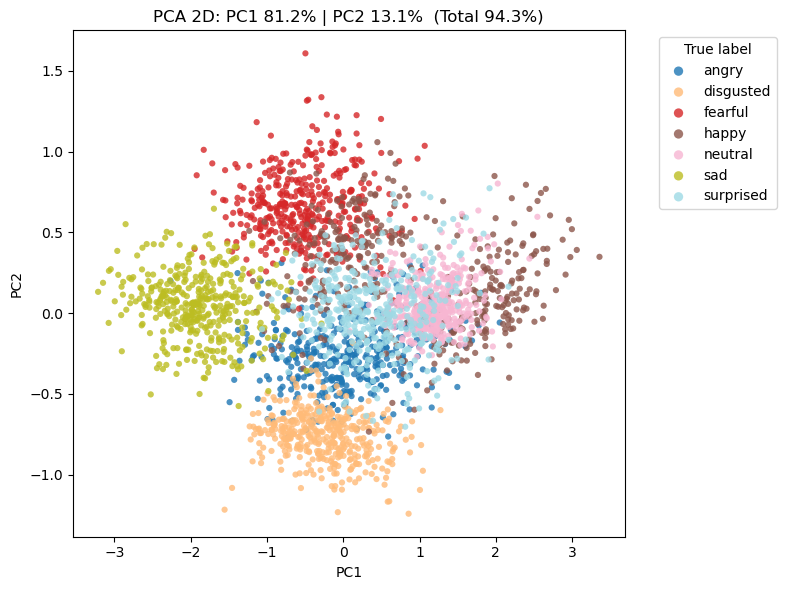

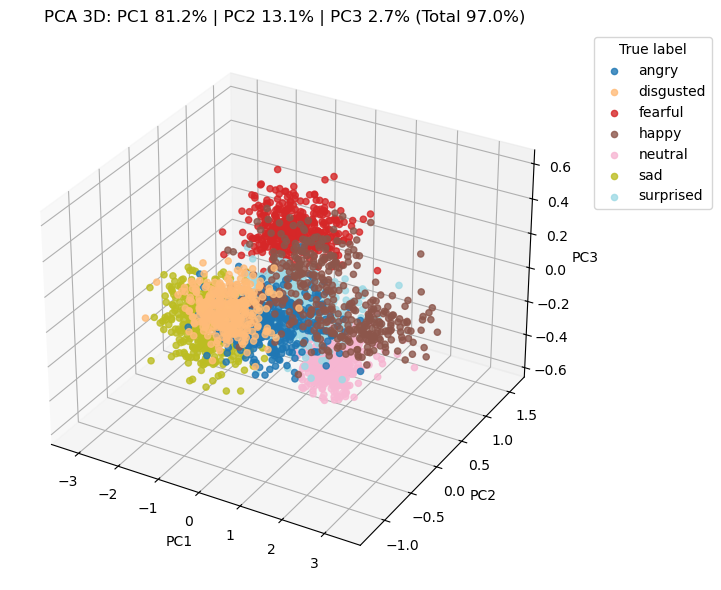

In [30]:
# Plot the PCA results (2D and 3D)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from PreprocessParams import LABEL_STRINGS

y = vector_df_glob_for_pca["true_label"].to_numpy()

labels = np.unique(y)

# Get the continuous colormap
cmap = mpl.colormaps.get_cmap("tab20")

# Sample exactly len(labels) colors
colors = cmap(np.linspace(0, 1, len(labels)))

# 2D scatter
plt.figure(figsize=(8, 6))
for i, lbl in enumerate(labels):
    
    lbl_idxs = (y == lbl)
    plt.scatter(
        X_pca2[lbl_idxs, 0], X_pca2[lbl_idxs, 1],
        s=20, alpha=0.8, color=colors[i], label=f"{lbl}", edgecolors="none"
    )
    
title2 = f"PCA 2D: PC1 {evr2[0]*100:.1f}% | PC2 {evr2[1]*100:.1f}%  (Total {evr2.sum()*100:.1f}%)"
plt.title(title2)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="True label", markerscale=1.5, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 3D scatter
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
for i, lbl in enumerate(labels):
    idx = (y == lbl)
    ax.scatter(
        X_pca3[idx, 0], X_pca3[idx, 1], X_pca3[idx, 2],
        s=20, alpha=0.8, color=colors[i], label=f"{lbl}"
    )
title3 = (
    f"PCA 3D: PC1 {evr3[0]*100:.1f}% | PC2 {evr3[1]*100:.1f}% | PC3 {evr3[2]*100:.1f}% "
    f"(Total {evr3.sum()*100:.1f}%)"
)
ax.set_title(title3)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend(title="True label", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## labels distribution accross clusters + Centroids

In [35]:
from tcav_demo import CONCEPT_UNIQUE_NAMES

def get_label_distribution_fitted(X, y, clustering_model, random_state=42, print_results=False):
    
    cluster_labels = clustering_model.predict(X)

    # Create a DataFrame to hold the cluster labels and true labels
    df = pd.DataFrame({'cluster': cluster_labels, 'true_label': y})

    # Get the distribution of clusters per true label
    label_distribution = df.groupby('true_label')['cluster'].value_counts(normalize=True).unstack(fill_value=0)

    #// # modify true_label to be the actual label names instead of numbers using LABEL_EMOTION_MAPPING
    
    #// label_distribution.index = label_distribution.index.map(label_mapping)
    
    # add cluster suffix to each column name
    label_distribution.columns = [f"{col} clus" for col in label_distribution.columns]
    
    # Create DataFrame for centroids
    centroids_df = pd.DataFrame(
        clustering_model.cluster_centers_,
        index=[f"cluster_{i}" for i in range(clustering_model.cluster_centers_.shape[0])],
        columns=[f"{concept}" for concept in CONCEPT_UNIQUE_NAMES]
    )

    if print_results:
        print("Cluster distribution across labels:")
        print(label_distribution)
        print("\nCluster centroids:")
        print(centroids_df)

    return label_distribution, centroids_df

def get_label_distribution_unfitted(X, y, clustering_model, random_state=42, print_results=False):
    clustering_model.fit(X)
    return get_label_distribution_fitted(X, y, clustering_model, random_state, print_results)

#? Example usage:
# lbl_dist, cent_df = get_label_distribution_unfitted(X, y, KMeans(n_clusters=4, random_state=42), print_results=False)
# display(lbl_dist)
# display(cent_df)

In [36]:
from pprint import pprint
from sklearn.preprocessing import normalize

X = vector_df_glob.drop(columns=["path", "true_label"], inplace=False).to_numpy()
y = vector_df_glob["true_label"].to_numpy()

# normalize X
X = normalize(X, norm='l2', axis=1)        # put points on the unit sphere

lbl_dist, cent_df = get_label_distribution_unfitted(X, y, KMeans(n_clusters=5, random_state=42), print_results=False)
display(lbl_dist)
display(cent_df)

c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(


,0 clus,1 clus,2 clus,3 clus,4 clus
true_label,,,,,
angry,0.002500,0.365000,0.230000,0.402500,0.000000
disgusted,0.000000,0.135000,0.010000,0.855000,0.000000
fearful,0.192500,0.020000,0.005000,0.000000,0.782500
happy,0.170000,0.105000,0.542500,0.017500,0.165000
neutral,0.002513,0.000000,0.992462,0.005025,0.000000
sad,0.000000,0.995000,0.000000,0.000000,0.005000
surprised,0.055696,0.237975,0.412658,0.227848,0.065823


,long-constant-thick,long-dropping-flat-thick,long-dropping-steep-thick,long-dropping-steep-thin,long-rising-flat-thick,long-rising-steep-thick,long-rising-steep-thin,short-constant-thick,short-dropping-steep-thick,short-dropping-steep-thin,short-rising-steep-thick,short-rising-steep-thin
cluster_0,-0.269225,0.448603,0.008688,0.096968,-0.280586,0.008752,-0.089700,-0.065941,0.024007,0.203624,-0.165400,-0.344492
cluster_1,-0.198362,-0.419987,-0.189371,-0.398831,-0.027119,-0.351031,-0.206208,-0.250860,-0.178562,-0.289623,-0.318241,-0.181116
cluster_2,0.330446,0.196909,0.240207,0.266937,0.221756,0.289311,0.311296,0.173825,0.147378,0.180614,0.361231,0.215868
cluster_3,-0.030814,-0.564450,0.152756,-0.314294,0.134191,-0.351181,0.073009,0.006227,0.015467,-0.232296,-0.032908,0.326756
cluster_4,-0.380300,-0.035178,-0.243611,-0.228550,-0.290226,-0.258528,-0.278032,-0.190200,-0.122702,-0.076334,-0.406735,-0.396820


## Create centroids per label

In [38]:
# for each label, compute its centroid all in a df
centroids_per_label = {}
for label in np.unique(y):
    label_idxs = np.where(y == label)[0]
    if len(label_idxs) > 0:
        centroids_per_label[label] = X[label_idxs].mean(axis=0)

centroids_df = pd.DataFrame(centroids_per_label).T

# for each column, set the name to be the concept name
centroids_df.columns = [f"{concept}" for concept in CONCEPT_UNIQUE_NAMES]
centroids_df

,long-constant-thick,long-dropping-flat-thick,long-dropping-steep-thick,long-dropping-steep-thin,long-rising-flat-thick,long-rising-steep-thick,long-rising-steep-thin,short-constant-thick,short-dropping-steep-thick,short-dropping-steep-thin,short-rising-steep-thick,short-rising-steep-thin
angry,-0.031822,-0.411623,-0.043831,-0.279876,0.104823,-0.163800,0.108433,-0.059252,0.029654,-0.189252,0.030524,0.186447
disgusted,-0.052068,-0.612416,0.137465,-0.321069,0.090285,-0.401412,-0.007632,0.031238,-0.008364,-0.242961,-0.109974,0.321082
fearful,-0.397050,0.057980,-0.216269,-0.171467,-0.296612,-0.216579,-0.228626,-0.188973,-0.073273,-0.027973,-0.364598,-0.397358
happy,0.009775,0.206976,0.090613,0.126602,-0.012793,0.095173,0.103719,0.095413,0.104805,0.092093,0.053391,-0.004674
neutral,0.466886,0.150418,0.185918,0.295303,0.264645,0.372119,0.258421,0.185016,0.060110,0.214027,0.359489,0.153236
sad,-0.197078,-0.368896,-0.235248,-0.383149,-0.025506,-0.339009,-0.246789,-0.293453,-0.212425,-0.301576,-0.354994,-0.269149
surprised,0.009975,-0.067612,0.243996,-0.087799,0.099507,-0.154183,0.101000,-0.067902,-0.001231,-0.027942,0.053416,0.089924


In [39]:
import numpy as np
import pandas as pd

class CentroidClassifier:
    """
    Classify by nearest centroid computed beforehand.
    centroids_df: DataFrame with index=emotion names, columns=concepts, values=centroid coords.
    metric: 'euclidean' | 'cosine' | 'manhattan'
    temperature: softmax temperature for predict_proba (smaller = sharper).
    """
    def __init__(self, centroids_df: pd.DataFrame, metric: str = "cosine", temperature: float = 1.0):
        self.metric = metric
        self.tau = float(temperature)
        self.labels_ = centroids_df.index.to_numpy()
        self.columns_ = centroids_df.columns
        self.cluster_centers_ = centroids_df.to_numpy(dtype=float)  # (n_centroids, d)

    def _to_array(self, X):
        # Accepts np.ndarray or DataFrame; if DF, align columns to centroids
        if isinstance(X, pd.DataFrame):
            missing = set(self.columns_) - set(X.columns)
            if missing:
                raise ValueError(f"X is missing columns: {sorted(missing)}")
            X = X.loc[:, self.columns_].to_numpy(dtype=float)
        else:
            X = np.asarray(X, dtype=float)
        if X.ndim == 1:
            X = X[None, :]
        return X

    def _distances(self, X):
        X = self._to_array(X)  # (n, d)
        if self.metric == "euclidean":
            d = np.sqrt(((X[:, None, :] - self.cluster_centers_[None, :, :]) ** 2).sum(axis=2))
        elif self.metric == "manhattan":
            d = np.abs(X[:, None, :] - self.cluster_centers_[None, :, :]).sum(axis=2)
        elif self.metric == "cosine":
            eps = 1e-12
            Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + eps)
            Cn = self.cluster_centers_ / (np.linalg.norm(self.cluster_centers_, axis=1, keepdims=True) + eps)
            d = 1.0 - Xn @ Cn.T
        else:
            raise ValueError(f"Unsupported metric: {self.metric}")
        return d  # shape (n_samples, n_centroids)

    def predict(self, X):
        d = self._distances(X)
        return self.labels_[d.argmin(axis=1)]

    def decision_function(self, X):
        # Higher is better (negative distance)
        return -self._distances(X)

    def predict_proba(self, X):
        # Softmax over negative distances (temperature = tau)
        s = self.decision_function(X) / self.tau
        s -= s.max(axis=1, keepdims=True)
        e = np.exp(s)
        return e / e.sum(axis=1, keepdims=True)  # shape (n_samples, n_centroids)

In [40]:
# Build classifier from your centroids
clf = CentroidClassifier(centroids_df, metric="cosine", temperature=0.5)

# Classify new samples in the same concept space (numpy array or DataFrame with same columns)
y_pred_names = clf.predict(X)              # array of emotion names (centroid labels)
probas = clf.predict_proba(X)              # soft assignment to each emotion (columns=centroids_df.index)

#// # If you need numeric IDs back (inverse of LABEL_EMOTION_MAPPING):
#// name_to_id = {v: k for k, v in label_mapping.items()}
#// y_pred_ids = np.vectorize(name_to_id.get)(y_pred_names)

In [41]:
# evaluate clustering on centroids_df using
# ---- STEP 4: Evaluation (since you have ground truth labels) ----
print("ARI:", adjusted_rand_score(y, y_pred_names))
print("Silhouette:", silhouette_score(X, y_pred_names))

# Intra-cluster and inter-cluster scores
print(intra_inter_scores(X, y_pred_names, metric="euclidean"))

ARI: 0.4274668631547243
Silhouette: 0.32303682422777186
{'intra_mean': 0.6144392056587125, 'inter_mean': 1.377367905837369, 'separation': 2.2416666989222396}


In [42]:
from pprint import pprint
from sklearn.preprocessing import normalize

X = vector_df_glob.drop(columns=["path", "true_label"], inplace=False).to_numpy()
y = vector_df_glob["true_label"].to_numpy()

# normalize X
X = normalize(X, norm='l2', axis=1)        # put points on the unit sphere

lbl_dist, cent_df = get_label_distribution_fitted(X, y, clf, print_results=False)
display(lbl_dist)
display(cent_df)

,angry clus,disgusted clus,fearful clus,happy clus,neutral clus,sad clus,surprised clus
true_label,,,,,,,
angry,0.352500,0.115000,0.00000,0.010000,0.180000,0.287500,0.055000
disgusted,0.020000,0.895000,0.00000,0.000000,0.002500,0.022500,0.060000
fearful,0.000000,0.000000,0.88500,0.050000,0.000000,0.065000,0.000000
happy,0.005000,0.012500,0.22750,0.192500,0.410000,0.127500,0.025000
neutral,0.002513,0.000000,0.00000,0.005025,0.992462,0.000000,0.000000
sad,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000
surprised,0.068354,0.101266,0.04557,0.113924,0.253165,0.243038,0.174684


,long-constant-thick,long-dropping-flat-thick,long-dropping-steep-thick,long-dropping-steep-thin,long-rising-flat-thick,long-rising-steep-thick,long-rising-steep-thin,short-constant-thick,short-dropping-steep-thick,short-dropping-steep-thin,short-rising-steep-thick,short-rising-steep-thin
cluster_0,-0.031822,-0.411623,-0.043831,-0.279876,0.104823,-0.163800,0.108433,-0.059252,0.029654,-0.189252,0.030524,0.186447
cluster_1,-0.052068,-0.612416,0.137465,-0.321069,0.090285,-0.401412,-0.007632,0.031238,-0.008364,-0.242961,-0.109974,0.321082
cluster_2,-0.397050,0.057980,-0.216269,-0.171467,-0.296612,-0.216579,-0.228626,-0.188973,-0.073273,-0.027973,-0.364598,-0.397358
cluster_3,0.009775,0.206976,0.090613,0.126602,-0.012793,0.095173,0.103719,0.095413,0.104805,0.092093,0.053391,-0.004674
cluster_4,0.466886,0.150418,0.185918,0.295303,0.264645,0.372119,0.258421,0.185016,0.060110,0.214027,0.359489,0.153236
cluster_5,-0.197078,-0.368896,-0.235248,-0.383149,-0.025506,-0.339009,-0.246789,-0.293453,-0.212425,-0.301576,-0.354994,-0.269149
cluster_6,0.009975,-0.067612,0.243996,-0.087799,0.099507,-0.154183,0.101000,-0.067902,-0.001231,-0.027942,0.053416,0.089924
